In [2]:
import pandas as pd
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders_per_customer = pd.read_csv('customer_database.csv')
unique_customers = len(orders_per_customer)

In [3]:
orders_per_customer['total_spent'].describe().round(2)

count    7753.00
mean      112.60
std       198.19
min        16.49
25%        35.95
50%        65.95
75%       102.95
max      7951.89
Name: total_spent, dtype: float64

In [4]:
ltv_by_country = (orders_per_customer.groupby('most_used_country')
    .agg({
        'total_spent': ['sum', 'mean'],
        'number_of_orders': 'mean',
        'most_used_country': 'count'
    })
    .reset_index())

ltv_by_country.columns = ['most_used_country', 'total_ltv_country', 'avg_ltv_country', 
                         'avg_orders_country', 'most_used_country_count']

ltv_by_country['total_ltv_country'] = ltv_by_country['total_ltv_country'].round(2)
ltv_by_country['avg_ltv_country'] = ltv_by_country['avg_ltv_country'].round(2)
ltv_by_country['avg_orders_country'] = ltv_by_country['avg_orders_country'].round(2)

ltv_by_country.to_csv('ltv_by_country.csv', index=False)
print('Saved to ltv_by_country.csv')

Saved to ltv_by_country.csv


In [5]:
def get_order_dates(row):
    dates = []
    for i in range(1, 11):
        order_col = f'order_{i}'
        if order_col in row and pd.notna(row[order_col]) and row[order_col]:
            parts = row[order_col].split(' - ')
            if parts and 'Date:' in parts[0]:
                date_str = parts[0].replace('Date:', '').strip()
                if re.match(r'\d{4}-\d{2}-\d{2}', date_str):
                    dates.append(date_str)
    return dates

orders_per_customer['order_dates'] = orders_per_customer.apply(get_order_dates, axis=1)

In [6]:
def get_first_order_date(order_dates):
    return min(pd.to_datetime(order_dates))

def first_order_in_period(order_dates, start_year, end_year):
    first_date = get_first_order_date(order_dates)
    return start_year <= first_date.year <= end_year

In [7]:
# 2018-2021
active_2018_2021 = orders_per_customer[
    orders_per_customer['order_dates'].apply(lambda x: first_order_in_period(x, 2018, 2021))
]
ltv_avg_2018_2021 = active_2018_2021['total_spent'].mean()
ltv_avg_2018_2021 = round(ltv_avg_2018_2021, 2)
unique_years_2018_2021 = sorted(active_2018_2021['order_dates'].apply(get_first_order_date).dt.year.unique())
print(f"LTV average of 3-Year customers (2018-2021, first order in period): €{ltv_avg_2018_2021}")
print("Number of first order customers from 2018-2021:", len(active_2018_2021))

# 2021-2024
active_2021_2024 = orders_per_customer[
    orders_per_customer['order_dates'].apply(lambda x: first_order_in_period(x, 2021, 2024))
]
ltv_avg_2021_2024 = active_2021_2024['total_spent'].mean()
ltv_avg_2021_2024 = round(ltv_avg_2021_2024, 2)
unique_years_2021_2024 = sorted(active_2021_2024['order_dates'].apply(get_first_order_date).dt.year.unique())
print(f"LTV Average of 3-Year Customers (2021-2024, first order in period): €{ltv_avg_2021_2024}")
print("Number of first order customers from 2021-2024:", len(active_2021_2024))

# 2022-2025
active_2022_2025 = orders_per_customer[
    orders_per_customer['order_dates'].apply(lambda x: first_order_in_period(x, 2022, 2025))
]
ltv_avg_2022_2025 = active_2022_2025['total_spent'].mean()
ltv_avg_2022_2025 = round(ltv_avg_2022_2025, 2)
unique_years_2022_2025 = sorted(active_2022_2025['order_dates'].apply(get_first_order_date).dt.year.unique())
print(f"LTV Average of 3-Year Customers (2022-2025, first order in period): €{ltv_avg_2022_2025}")
print("Number of first order customers from 2022-2025:", len(active_2022_2025))

LTV average of 3-Year customers (2018-2021, first order in period): €113.23
Number of first order customers from 2018-2021: 6191
LTV Average of 3-Year Customers (2021-2024, first order in period): €104.62
Number of first order customers from 2021-2024: 4132
LTV Average of 3-Year Customers (2022-2025, first order in period): €110.12
Number of first order customers from 2022-2025: 1562


In [8]:
repeat_customers = orders_per_customer[orders_per_customer['number_of_orders'] > 1]
ltv_avg_repeat = repeat_customers['total_spent'].mean().round(2)
print(f"LTV Average of Repeat Buying Customers: €{ltv_avg_repeat}")

LTV Average of Repeat Buying Customers: €259.33


In [9]:
top_10_percentile = orders_per_customer['total_spent'].quantile(0.9)
top_10_customers = orders_per_customer[orders_per_customer['total_spent'] >= top_10_percentile]
ltv_avg_top_10 = top_10_customers['total_spent'].mean().round(2)
print(f"LTV Average of Top 10% Customers: €{ltv_avg_top_10}")

LTV Average of Top 10% Customers: €498.19


In [10]:
def get_products(row):
    products = set()
    for i in range(1, 1001):
        order_col = f'order_{i}'
        if order_col in row and pd.notna(row[order_col]) and row[order_col]:
            parts = row[order_col].split(' - ')
            if len(parts) > 1:
                items_part = parts[1].split(' - Spent:')[0]
                items_str = items_part.replace('Product(s):', '').strip()
                items = re.split(r',| and ', items_str)
                for item in items:
                    item = item.strip()
                    if item:
                        if 'CS2X3' in item:
                            normalized_item = 'CS2'
                        elif 'CS1X3' in item:
                            normalized_item = 'CS1'
                        elif 'CS2' in item:
                            normalized_item = 'CS2'
                        elif 'CS1' in item:
                            normalized_item = 'CS1'
                        elif item == 'Consultation':
                            continue
                        else:
                            normalized_item = item
                        products.add(normalized_item)
    return products

orders_per_customer['products'] = orders_per_customer.apply(get_products, axis=1)

product_ltv = {}
all_products = set()
orders_per_customer['products'].apply(lambda x: all_products.update(x))

for product in all_products:
    customers_with_product = orders_per_customer[
        orders_per_customer['products'].apply(lambda x: product in x)
    ]
    mean_ltv = customers_with_product['total_spent'].mean()
    product_ltv[product] = round(mean_ltv, 2)

print("LTV Average per Product:")
for product, ltv in product_ltv.items():
    print(f"  {product}: €{ltv}")

LTV Average per Product:
  ARP: €206.09
  OPG: €264.04
  SSG: €261.89
  Eye Drops: €268.51
  Oregano Oil: €218.77
  CS1: €169.41
  SPF: €160.49
  MB: €185.44
  ACV: €169.39
  Probiotics: €251.9
  CS2: €131.72
  Eye Spray: €246.71


In [11]:
def extract_products_from_order(order_str):
    if pd.notna(order_str) and order_str:
        parts = order_str.split(' - ')
        if len(parts) > 1:
            items_part = parts[1].split(' - Spent:')[0]
            items_str = items_part.replace('Product(s):', '').strip()
            items = re.split(r',| and ', items_str)
            products = set()
            for item in items:
                item = item.strip()
                if item:
                    if 'CS2X3' in item:
                        normalized_item = 'CS2'
                    elif 'CS1X3' in item:
                        normalized_item = 'CS1'
                    elif 'CS2' in item:
                        normalized_item = 'CS2'
                    elif 'CS1' in item:
                        normalized_item = 'CS1'
                    elif item == 'Consultation':
                        continue
                    else:
                        normalized_item = item
                    products.add(normalized_item)
            return products
    return set()

In [12]:
total_customers = orders_per_customer.shape[0]
total_orders = orders_per_customer['number_of_orders'].sum()
average_orders_per_customer = total_orders / total_customers

print(f"Total Customers: {total_customers}")
print(f"Total Orders: {total_orders}")
print(f"Average Orders per Customer: {average_orders_per_customer:.2f}")

Total Customers: 7753
Total Orders: 14608
Average Orders per Customer: 1.88


In [13]:
repeat_customers = orders_per_customer[orders_per_customer['number_of_orders'] > 1]

total_repeat_customers = repeat_customers.shape[0]
total_repeat_orders = repeat_customers['number_of_orders'].sum()
average_orders_per_repeat_customer = total_repeat_orders / total_repeat_customers

print(f"Total Repeat Customers: {total_repeat_customers}")
print(f"Total Orders by Repeat Customers: {total_repeat_orders}")
print(f"Average Orders per Repeat Customer: {average_orders_per_repeat_customer:.2f}")

Total Repeat Customers: 2166
Total Orders by Repeat Customers: 9021
Average Orders per Repeat Customer: 4.16


In [14]:
def get_product_details(row):
    product_counts = {}
    all_products = set()
    for i in range(1, 1001):
        order_col = f'order_{i}'
        if order_col in row and pd.notna(row[order_col]) and row[order_col]:
            order_products = extract_products_from_order(row[order_col])
            for product in order_products:
                product_counts[product] = product_counts.get(product, 0) + 1
                all_products.add(product)
    return {'counts': product_counts, 'all_products': all_products}

orders_per_customer['product_details'] = orders_per_customer.apply(get_product_details, axis=1)

all_products = set()
orders_per_customer['product_details'].apply(lambda x: all_products.update(x['counts'].keys()))

product_breakdowns = {}
for product in all_products:
    product_customers = orders_per_customer[
        orders_per_customer['product_details'].apply(lambda x: product in x['counts'])
    ]
    total_buyers = product_customers.shape[0]

    once_no_repeat = product_customers[
        (product_customers['number_of_orders'] == 1) & 
        (product_customers['product_details'].apply(lambda x: x['counts'].get(product, 0) == 1))
    ].shape[0]

    once_with_other = product_customers[
        (product_customers['number_of_orders'] > 1) & 
        (product_customers['product_details'].apply(lambda x: x['counts'].get(product, 0) == 1)) &
        (product_customers['product_details'].apply(lambda x: len(x['all_products']) > 1))
    ].shape[0]

    repeat_buyers = product_customers[
        product_customers['product_details'].apply(lambda x: x['counts'].get(product, 0) > 1)
    ].shape[0]

    once_no_repeat_pct = (once_no_repeat / total_buyers * 100) if total_buyers > 0 else 0
    once_with_other_pct = (once_with_other / total_buyers * 100) if total_buyers > 0 else 0
    repeat_buyers_pct = (repeat_buyers / total_buyers * 100) if total_buyers > 0 else 0

    product_breakdowns[product] = {
        'total_buyers': total_buyers,
        'once_no_repeat': once_no_repeat,
        'once_no_repeat_pct': round(once_no_repeat_pct, 2),
        'once_with_other': once_with_other,
        'once_with_other_pct': round(once_with_other_pct, 2),
        'repeat_buyers': repeat_buyers,
        'repeat_buyers_pct': round(repeat_buyers_pct, 2)
    }

print("Repeat Buying Breakdown per Product:")
for product in sorted(product_breakdowns.keys()):
    stats = product_breakdowns[product]
    print(f"\n{product} (Total Buyers: {stats['total_buyers']}):")
    print(f"  Bought once, no other orders: {stats['once_no_repeat']} ({stats['once_no_repeat_pct']}%)")
    print(f"  Bought once, then another product: {stats['once_with_other']} ({stats['once_with_other_pct']}%)")
    print(f"  Bought multiple times (Repeat Buyers): {stats['repeat_buyers']} ({stats['repeat_buyers_pct']}%)")

total_buyers_sum = sum(stats['total_buyers'] for stats in product_breakdowns.values())
once_sum = sum(stats['once_no_repeat'] for stats in product_breakdowns.values())
with_others_sum = sum(stats['once_with_other'] for stats in product_breakdowns.values())
repeat_buyers_sum = sum(stats['repeat_buyers'] for stats in product_breakdowns.values())

print(f"\nSum of Total Buyers across products: {total_buyers_sum}")
print(f"Sum of One Order Buyers across products: {once_sum}")
print(f"Sum of Once then another across products: {with_others_sum}")
print(f"Sum of Repeat Buyers across products: {repeat_buyers_sum}")

Repeat Buying Breakdown per Product:

ACV (Total Buyers: 1676):
  Bought once, no other orders: 986 (58.83%)
  Bought once, then another product: 519 (30.97%)
  Bought multiple times (Repeat Buyers): 171 (10.2%)

ARP (Total Buyers: 1322):
  Bought once, no other orders: 731 (55.3%)
  Bought once, then another product: 473 (35.78%)
  Bought multiple times (Repeat Buyers): 118 (8.93%)

CS1 (Total Buyers: 2847):
  Bought once, no other orders: 1747 (61.36%)
  Bought once, then another product: 512 (17.98%)
  Bought multiple times (Repeat Buyers): 588 (20.65%)

CS2 (Total Buyers: 4368):
  Bought once, no other orders: 2788 (63.83%)
  Bought once, then another product: 396 (9.07%)
  Bought multiple times (Repeat Buyers): 1184 (27.11%)

Eye Drops (Total Buyers: 307):
  Bought once, no other orders: 164 (53.42%)
  Bought once, then another product: 119 (38.76%)
  Bought multiple times (Repeat Buyers): 24 (7.82%)

Eye Spray (Total Buyers: 242):
  Bought once, no other orders: 114 (47.11%)
  Bo

In [15]:
def get_order1_product_details(row):
    product_counts = {}
    all_products = set()
    order_col = 'order_1'
    if order_col in row and pd.notna(row[order_col]) and row[order_col]:
        order_products = extract_products_from_order(row[order_col])
        for product in order_products:
            product_counts[product] = 1
            all_products.add(product)
    
    for i in range(2, 1001):
        order_col = f'order_{i}'
        if order_col in row and pd.notna(row[order_col]) and row[order_col]:
            order_products = extract_products_from_order(row[order_col])
            for product in order_products:
                if product in product_counts:
                    product_counts[product] += 1
    
    return {'counts': product_counts, 'all_products': all_products}

orders_per_customer['product_details'] = orders_per_customer.apply(get_order1_product_details, axis=1)

all_products = set()
orders_per_customer['product_details'].apply(lambda x: all_products.update(x['counts'].keys()))

product_breakdowns_1 = {}
for product in all_products:
    product_customers = orders_per_customer[
        orders_per_customer['product_details'].apply(lambda x: product in x['counts'])
    ]
    total_buyers_1 = product_customers.shape[0]

    once_no_repeat_1 = product_customers[
        (product_customers['number_of_orders'] == 1) & 
        (product_customers['product_details'].apply(lambda x: x['counts'].get(product, 0) == 1))
    ].shape[0]

    once_with_other_orders_1 = product_customers[
        (product_customers['number_of_orders'] > 1) & 
        (product_customers['product_details'].apply(lambda x: x['counts'].get(product, 0) == 1))
    ].shape[0]

    repeat_buyers_1 = product_customers[
        product_customers['product_details'].apply(lambda x: x['counts'].get(product, 0) > 1)
    ].shape[0]

    once_no_repeat_pct_1 = (once_no_repeat_1 / total_buyers_1 * 100) if total_buyers_1 > 0 else 0
    once_with_other_orders_pct_1 = (once_with_other_orders_1 / total_buyers_1 * 100) if total_buyers_1 > 0 else 0
    repeat_buyers_pct_1 = (repeat_buyers_1 / total_buyers_1 * 100) if total_buyers_1 > 0 else 0

    product_breakdowns_1[product] = {
        'total_buyers_1': total_buyers_1,
        'once_no_repeat_1': once_no_repeat_1,
        'once_no_repeat_pct_1': round(once_no_repeat_pct_1, 2),
        'once_with_other_orders_1': once_with_other_orders_1,
        'once_with_other_orders_pct_1': round(once_with_other_orders_pct_1, 2),
        'repeat_buyers_1': repeat_buyers_1,
        'repeat_buyers_pct_1': round(repeat_buyers_pct_1, 2)
    }

print("Repeat Buying Breakdown per Product (Based on first order Purchases):")
for product in sorted(product_breakdowns_1.keys()):
    stats = product_breakdowns_1[product]
    print(f"\n{product} (Total Buyers in first order: {stats['total_buyers_1']}):")
    print(f"  Bought in first order, no other orders: {stats['once_no_repeat_1']} ({stats['once_no_repeat_pct_1']}%)")
    print(f"  Bought in first order, other orders but no repeat: {stats['once_with_other_orders_1']} ({stats['once_with_other_orders_pct_1']}%)")
    print(f"  Bought in first order and repeated later: {stats['repeat_buyers_1']} ({stats['repeat_buyers_pct_1']}%)")

total_buyers_1_sum = sum(stats['total_buyers_1'] for stats in product_breakdowns_1.values())
once_no_repeat_1_sum = sum(stats['once_no_repeat_1'] for stats in product_breakdowns_1.values())
once_with_other_1_sum = sum(stats['once_with_other_orders_1'] for stats in product_breakdowns_1.values())
repeat_buyers_1_sum = sum(stats['repeat_buyers_1'] for stats in product_breakdowns_1.values())

print(f"\nSum of Total Buyers from first order across products: {total_buyers_1_sum}")
print(f"Sum of One Order Only Buyers across products: {once_no_repeat_1_sum}")
print(f"Sum of Once with Other Orders across products: {once_with_other_1_sum}")
print(f"Sum of Repeat Buyers across products: {repeat_buyers_1_sum}")

Repeat Buying Breakdown per Product (Based on first order Purchases):

ACV (Total Buyers in first order: 1460):
  Bought in first order, no other orders: 986 (67.53%)
  Bought in first order, other orders but no repeat: 330 (22.6%)
  Bought in first order and repeated later: 144 (9.86%)

ARP (Total Buyers in first order: 1023):
  Bought in first order, no other orders: 731 (71.46%)
  Bought in first order, other orders but no repeat: 216 (21.11%)
  Bought in first order and repeated later: 76 (7.43%)

CS1 (Total Buyers in first order: 2456):
  Bought in first order, no other orders: 1747 (71.13%)
  Bought in first order, other orders but no repeat: 231 (9.41%)
  Bought in first order and repeated later: 478 (19.46%)

CS2 (Total Buyers in first order: 4056):
  Bought in first order, no other orders: 2788 (68.74%)
  Bought in first order, other orders but no repeat: 199 (4.91%)
  Bought in first order and repeated later: 1069 (26.36%)

Eye Drops (Total Buyers in first order: 209):
  Boug

In [16]:
product_df = pd.DataFrame.from_dict(product_breakdowns, orient='index').reset_index()
product_df.columns = [
    'Product', 'Total_Buyers', 'Once_No_Other_Orders', 'Once_No_Other_Pct',
    'Once_Then_Another', 'Once_Then_Another_Pct', 'Repeat_Buyers', 'Repeat_Buyers_Pct'
]

output_folder = 'LTV_Results'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

product_df.to_csv(os.path.join(output_folder, 'product_repeat_buying.csv'), index=False)
print("Product-level data saved to LTV_Results/'product_repeat_buying.csv'")

summary_data = {
    'Metric': ['Total_Buyers_Across_Products', 'One_Order_Buyers', 'Once_Then_Another', 'Repeat_Buyers', 'Unique_Customers'],
    'Value': [total_buyers_sum, once_sum, with_others_sum, repeat_buyers_sum, unique_customers]
}
summary_df = pd.DataFrame(summary_data)

summary_df.to_csv(os.path.join(output_folder, 'overall_repeat_summary.csv'), index=False)
print("Summary data saved to LTV_Results/'overall_repeat_summary.csv'")

Product-level data saved to LTV_Results/'product_repeat_buying.csv'
Summary data saved to LTV_Results/'overall_repeat_summary.csv'


In [17]:
def cohort_product_details(row):
    customer_orders = []
    for i in range(1, 1001):
        order_col = f'order_{i}'
        if order_col in row and pd.notna(row[order_col]) and row[order_col]:
            order_str = row[order_col]
            parts = order_str.split(' - ')
            order_date = 'Unknown'
            if parts[0].startswith('Date:'):
                date_str = parts[0].replace('Date:', '').strip()
                if pd.to_datetime(date_str, errors='coerce') is not pd.NaT:
                    order_date = date_str
            products = extract_products_from_order(order_str)
            revenue = 0.0
            for part in parts:
                if 'Spent:' in part:
                    revenue_str = part.replace('Spent:', '').strip('()')
                    try:
                        revenue = float(revenue_str)
                    except ValueError:
                        revenue = 0.0
                    break
            customer_orders.append({
                'order_date': order_date,
                'products': products,
                'revenue': revenue
            })
    return customer_orders

orders_per_customer['orders'] = orders_per_customer.apply(cohort_product_details, axis=1)

cohort_data = []
for idx, row in orders_per_customer.iterrows():
    customer_id = idx
    if 'order_1' not in row or pd.isna(row['order_1']) or not row['order_1']:
        continue
    order_1_str = row['order_1']
    parts = order_1_str.split(' - ')
    first_order_date = 'Unknown'
    if parts[0].startswith('Date:'):
        date_str = parts[0].replace('Date:', '').strip()
        if pd.to_datetime(date_str, errors='coerce') is not pd.NaT:
            first_order_date = date_str
    if first_order_date == 'Unknown':
        continue
    cohort = pd.to_datetime(first_order_date).strftime('%Y-%m')
    orders = row['orders']
    monthly_revenue = {}
    for order in orders:
        if order['order_date'] == 'Unknown':
            continue
        order_date = pd.to_datetime(order['order_date'])
        months_since = (order_date.year - pd.to_datetime(first_order_date).year) * 12 + \
                       (order_date.month - pd.to_datetime(first_order_date).month)
        monthly_revenue[months_since] = monthly_revenue.get(months_since, 0) + order['revenue']
    cohort_data.append({
        'customer_id': customer_id,
        'cohort': cohort,
        'orders': orders,
        'monthly_revenue': monthly_revenue
    })

cohort_agg = {}
for entry in cohort_data:
    cohort = entry['cohort']
    if cohort not in cohort_agg:
        cohort_agg[cohort] = {'size': 0, 'orders': 0, 'revenue_by_month': {}}
    cohort_agg[cohort]['size'] += 1
    cohort_agg[cohort]['orders'] += len(entry['orders'])
    for month, revenue in entry['monthly_revenue'].items():
        cohort_agg[cohort]['revenue_by_month'][month] = \
            cohort_agg[cohort]['revenue_by_month'].get(month, 0) + revenue

max_months = 0
for entry in cohort_data:
    if entry['monthly_revenue']:
        max_month = max(entry['monthly_revenue'].keys())
        max_months = max(max_months, max_month)

cohort_df_data = []
for cohort, data in cohort_agg.items():
    cohort_size = data['size']
    cum_revenue = 0
    row = {
        'Cohort': cohort,
        'Cohort_Size': cohort_size,
        'Cohort_Orders': data['orders']
    }
    for month in range(max_months + 1):
        revenue_change = data['revenue_by_month'].get(month, 0)
        cum_revenue += revenue_change
        row[str(month)] = round(cum_revenue / cohort_size, 2)
    cohort_df_data.append(row)

cohort_df_data = sorted(cohort_df_data, key=lambda x: x['Cohort'])

cohort_df = pd.DataFrame(cohort_df_data)
cohort_df.to_csv('cohort_ltv.csv', index=False)
print("Cohort LTV data saved to 'cohort_ltv.csv'")

Cohort LTV data saved to 'cohort_ltv.csv'


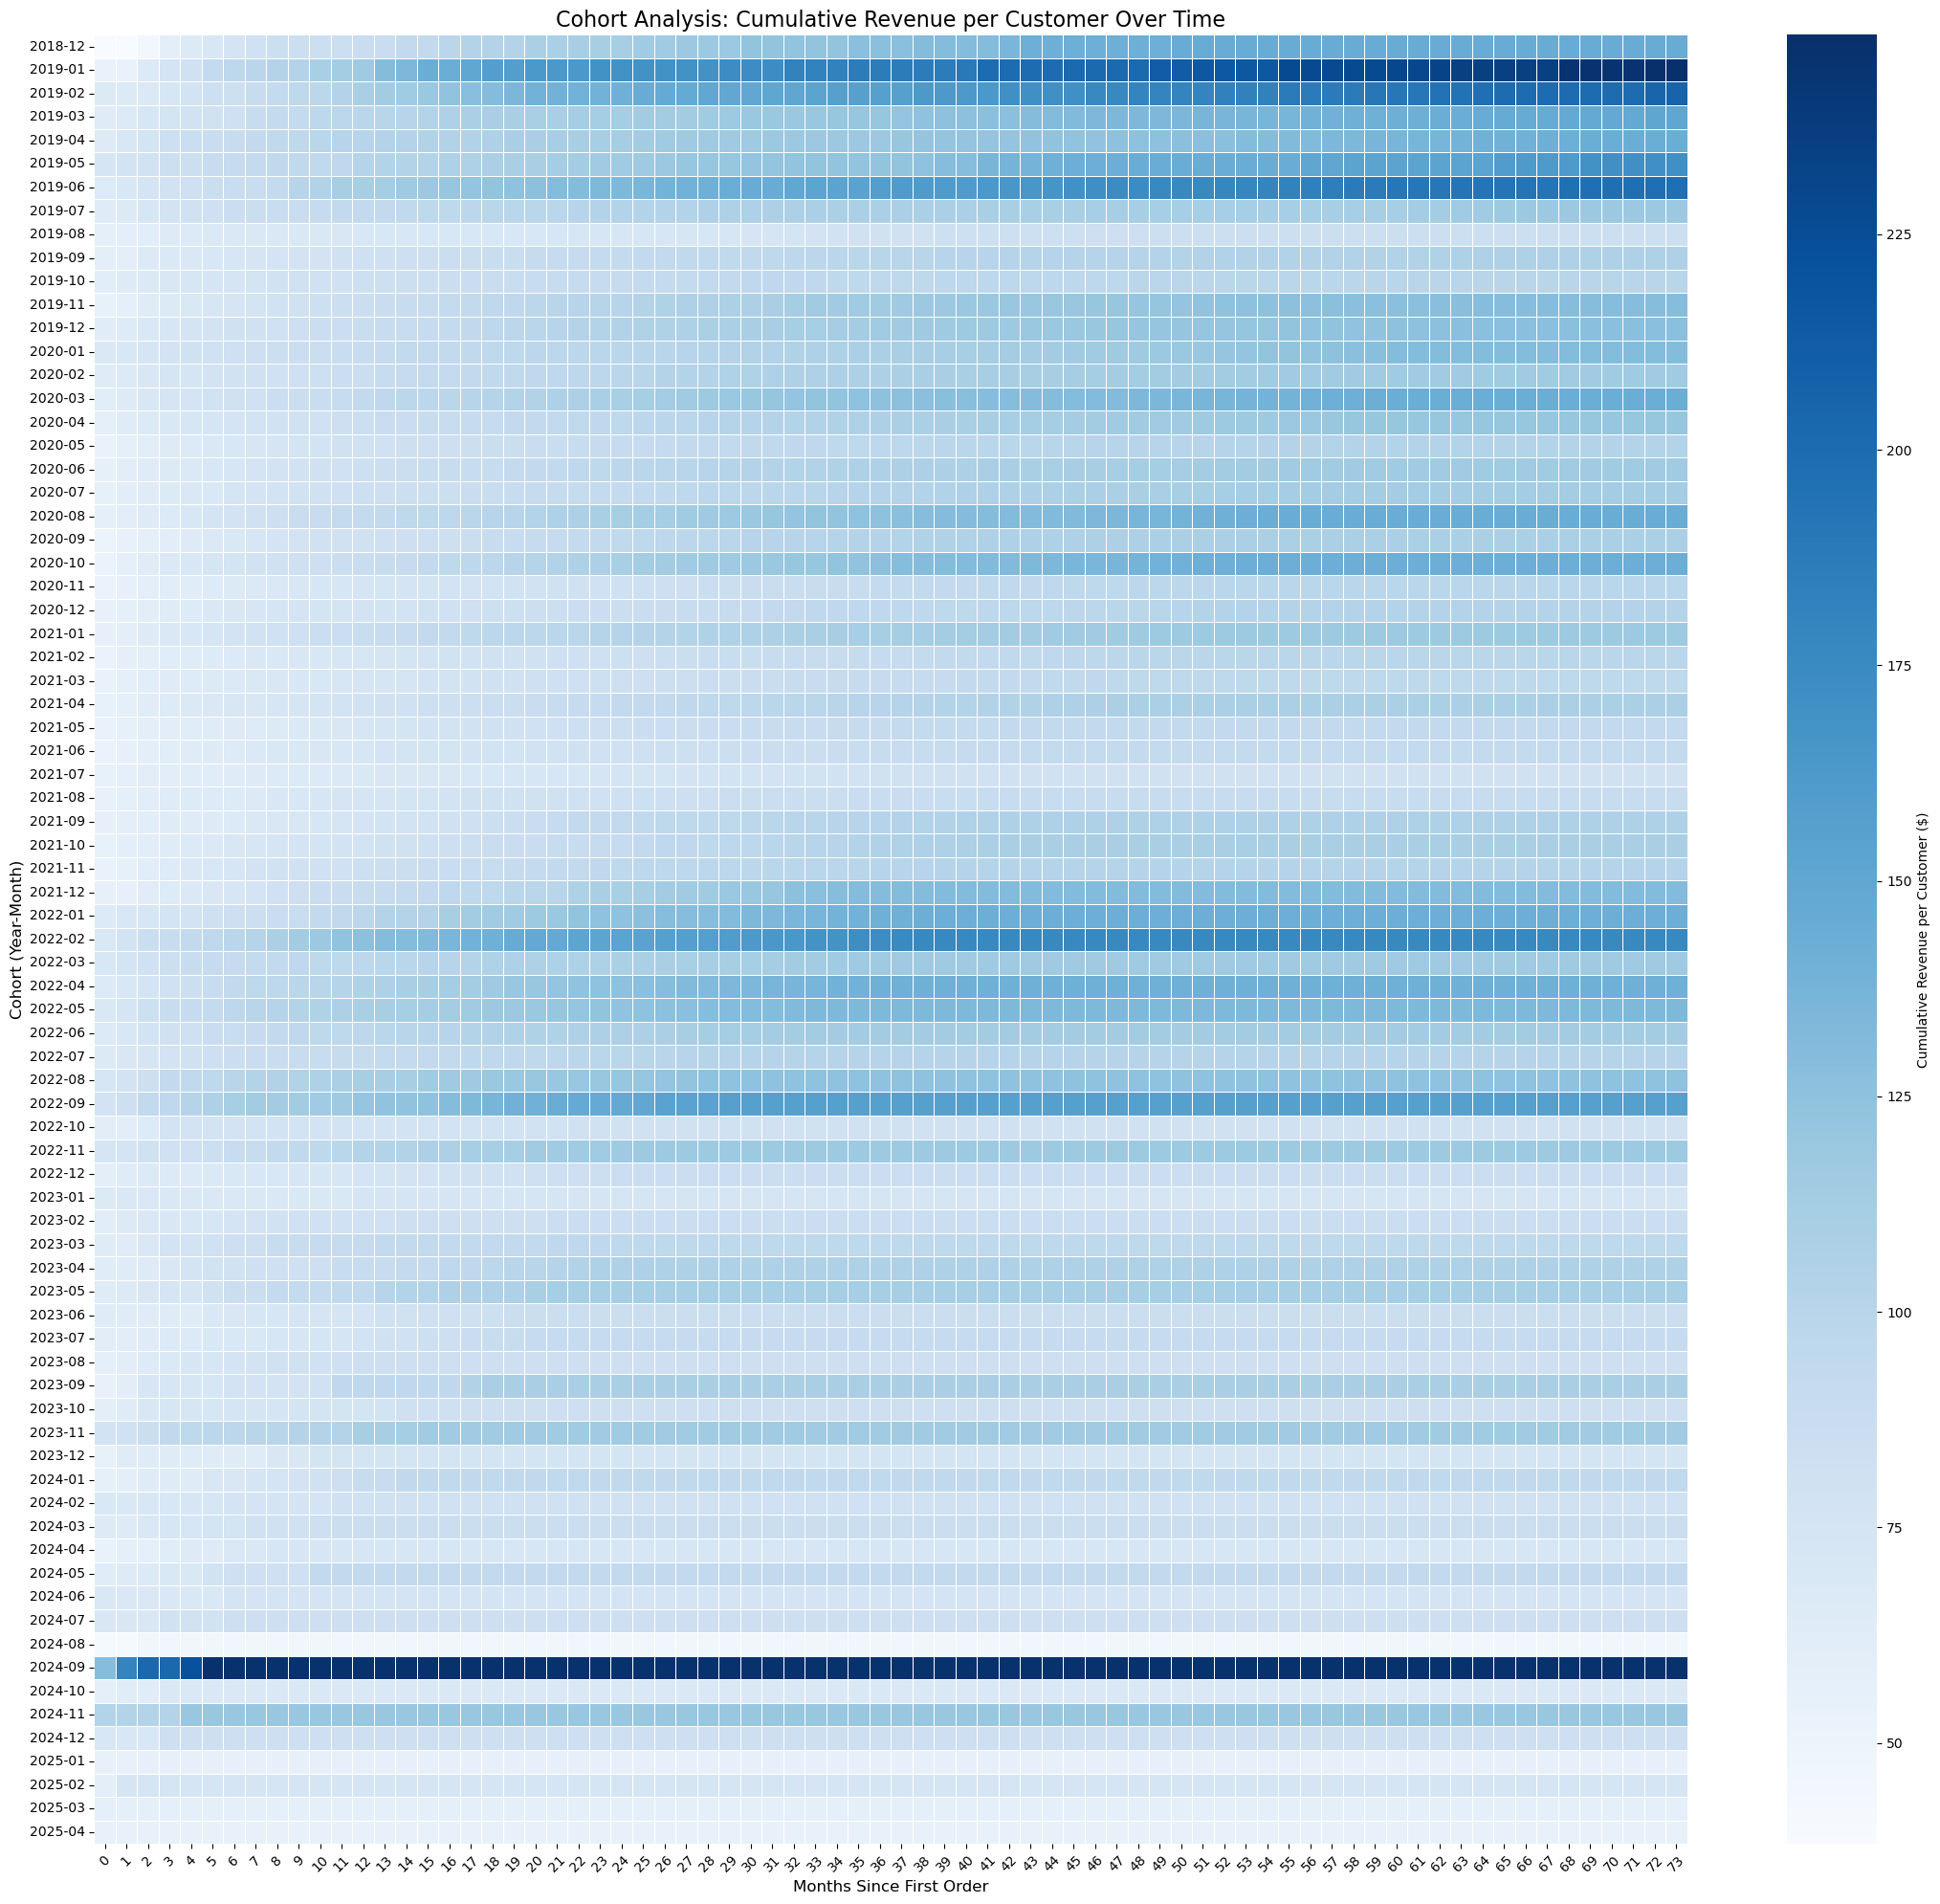

In [ ]:
heatmap_data = cohort_df.drop(columns=['Cohort_Size', 'Cohort_Orders']).set_index('Cohort')

plt.figure(figsize=(22, 20)) # Adjust the second number in figsize to see the months
sns.heatmap(
    heatmap_data,
    cmap='Blues',
    cbar_kws={'label': 'Cumulative Revenue per Customer ($)'},
    linewidths=0.5,
)
plt.title('Cohort Analysis: Cumulative Revenue per Customer Over Time', fontsize=16)
plt.xlabel('Months Since First Order', fontsize=12)
plt.ylabel('Cohort (Year-Month)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()


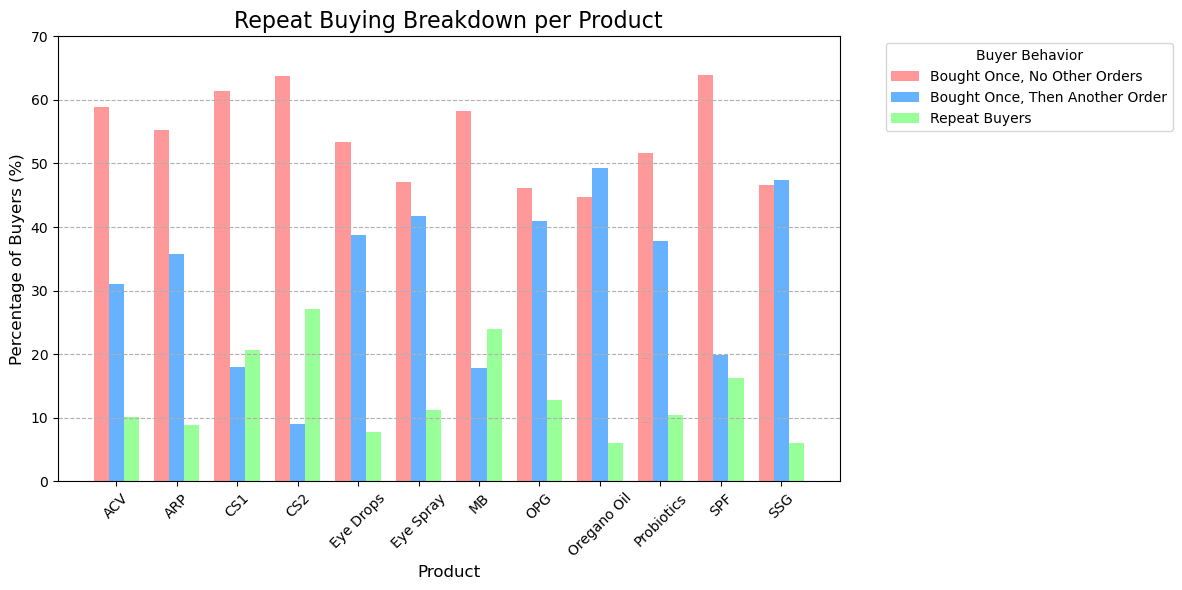

In [19]:
products = sorted(product_breakdowns.keys())
once_no_repeat_pct = [product_breakdowns[p]['once_no_repeat_pct'] for p in products]
once_with_other_pct = [product_breakdowns[p]['once_with_other_pct'] for p in products]
repeat_buyers_pct = [product_breakdowns[p]['repeat_buyers_pct'] for p in products]
total_buyers = [product_breakdowns[p]['total_buyers'] for p in products]

pct_data = {
    'Product': products,
    'Bought Once, No Other Orders (%)': once_no_repeat_pct,
    'Bought Once, Then Another Order (%)': once_with_other_pct,
    'Repeat Buyers (%)': repeat_buyers_pct,
    'Total Buyers': total_buyers
}
pct_df = pd.DataFrame(pct_data)

plt.figure(figsize=(12, 6))
bar_width = 0.25
index = np.arange(len(products))

plt.bar(index, pct_df['Bought Once, No Other Orders (%)'], 
        bar_width, label='Bought Once, No Other Orders', color='#FF9999')
plt.bar(index + bar_width, pct_df['Bought Once, Then Another Order (%)'], 
        bar_width, label='Bought Once, Then Another Order', color='#66B2FF')
plt.bar(index + 2 * bar_width, pct_df['Repeat Buyers (%)'], 
        bar_width, label='Repeat Buyers', color='#99FF99')

plt.title('Repeat Buying Breakdown per Product', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Percentage of Buyers (%)', fontsize=12)
plt.xticks(index + bar_width, pct_df['Product'], rotation=45)
plt.ylim(0, 70)
plt.legend(title='Buyer Behavior', bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

plt.show()

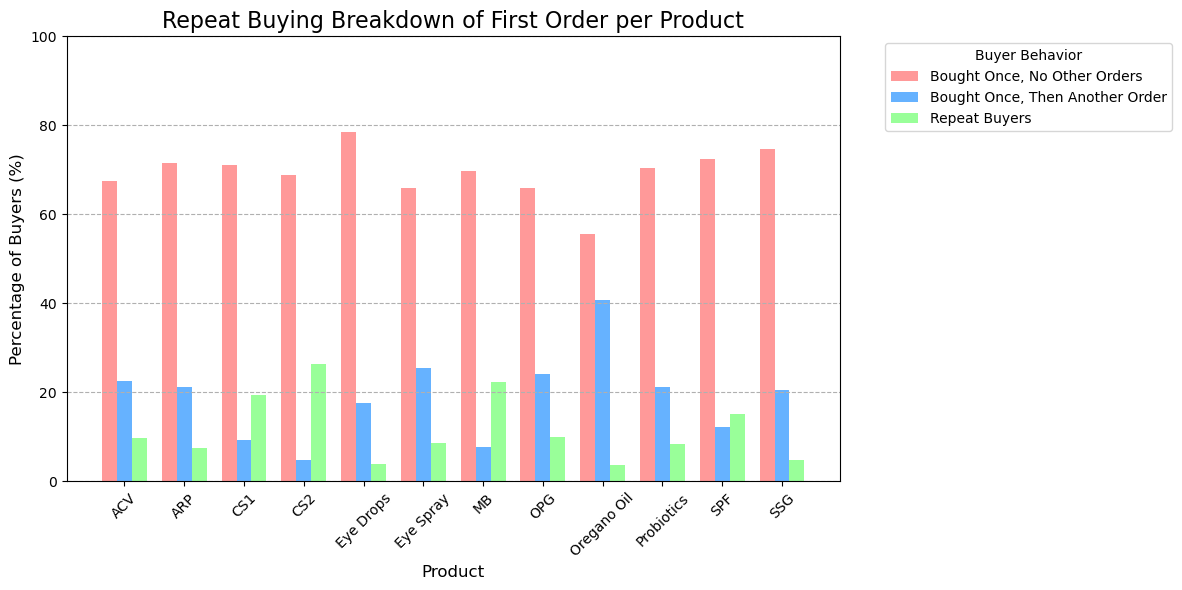

In [20]:
products_1 = sorted(product_breakdowns_1.keys())
once_no_repeat_pct_1 = [product_breakdowns_1[p]['once_no_repeat_pct_1'] for p in products_1]
once_with_other_orders_pct_1 = [product_breakdowns_1[p]['once_with_other_orders_pct_1'] for p in products_1]
repeat_buyers_pct_1 = [product_breakdowns_1[p]['repeat_buyers_pct_1'] for p in products_1]
total_buyers_1 = [product_breakdowns_1[p]['total_buyers_1'] for p in products_1]

data_1 = {
    'Product': products_1,
    'Bought Once, No Other Orders (%)': once_no_repeat_pct_1,
    'Bought Once, Then Another Order (%)': once_with_other_orders_pct_1,
    'Repeat Buyers (%)': repeat_buyers_pct_1,
    'Total Buyers': total_buyers_1
}
df_1 = pd.DataFrame(data_1)

plt.figure(figsize=(12, 6))
bar_width = 0.25
index = np.arange(len(products))

plt.bar(index, df_1['Bought Once, No Other Orders (%)'], 
        bar_width, label='Bought Once, No Other Orders', color='#FF9999')
plt.bar(index + bar_width, df_1['Bought Once, Then Another Order (%)'], 
        bar_width, label='Bought Once, Then Another Order', color='#66B2FF')
plt.bar(index + 2 * bar_width, df_1['Repeat Buyers (%)'], 
        bar_width, label='Repeat Buyers', color='#99FF99')

plt.title('Repeat Buying Breakdown of First Order per Product', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Percentage of Buyers (%)', fontsize=12)
plt.xticks(index + bar_width, df_1['Product'], rotation=45)
plt.ylim(0, 100)
plt.legend(title='Buyer Behavior', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

plt.show()

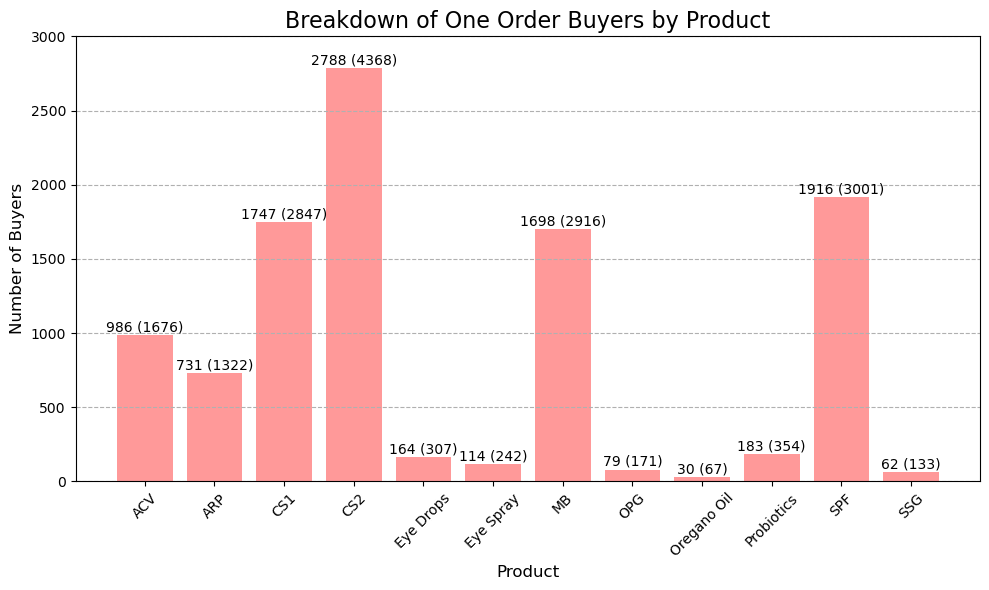

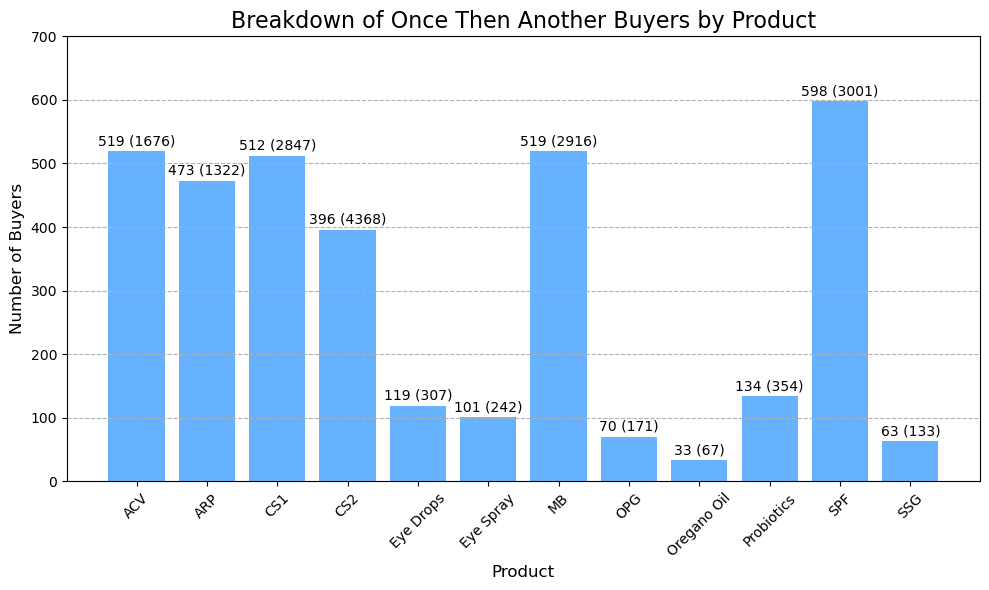

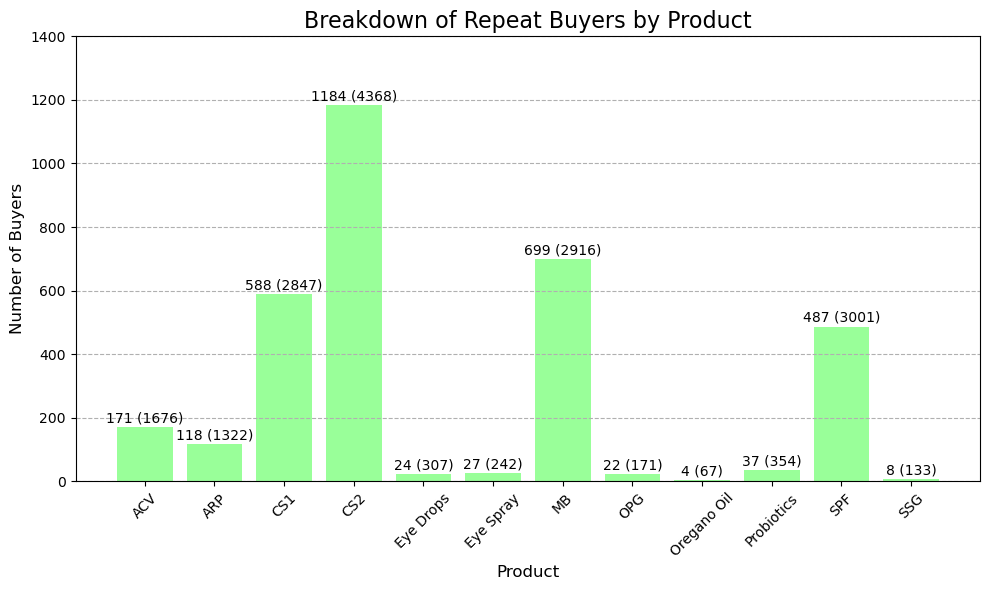

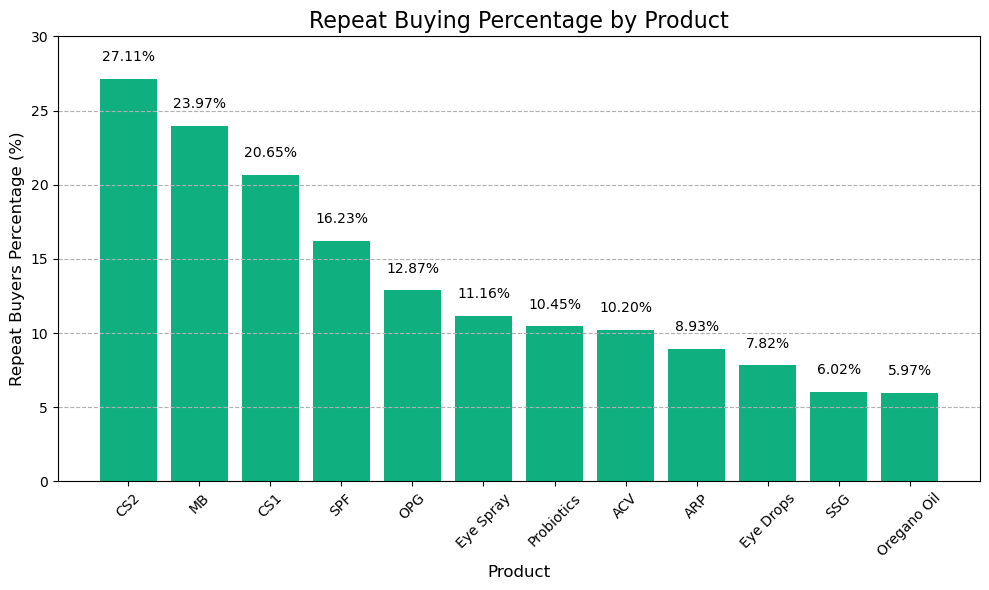

In [21]:
once_no_repeat_counts = [product_breakdowns[p]['once_no_repeat'] for p in products]
once_with_other_counts = [product_breakdowns[p]['once_with_other'] for p in products]
repeat_buyers_counts = [product_breakdowns[p]['repeat_buyers'] for p in products]
repeat_buyers_pct = [product_breakdowns[p]['repeat_buyers_pct'] for p in products]
total_buyers = [product_breakdowns[p]['total_buyers'] for p in products]

data = {
    'Product': products,
    'One Order Buyers': once_no_repeat_counts,
    'Once Then Another': once_with_other_counts,
    'Repeat Buyers': repeat_buyers_counts,
    'Repeat Buyers (%)': repeat_buyers_pct,
    'Total Buyers': total_buyers
}
df = pd.DataFrame(data)

# Plot 1: One Order Buyers Breakdown
plt.figure(figsize=(10, 6))
plt.bar(df['Product'], df['One Order Buyers'], color='#FF9999')
plt.title('Breakdown of One Order Buyers by Product', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)
plt.xticks(rotation=45)
for i, (count, total) in enumerate(zip(df['One Order Buyers'], df['Total Buyers'])):
    plt.text(i, count + 5, f'{count} ({total})', ha='center', va='bottom', fontsize=10)
plt.ylim(0, 3000)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Plot 2: Once Then Another Breakdown
plt.figure(figsize=(10, 6))
plt.bar(df['Product'], df['Once Then Another'], color='#66B2FF')
plt.title('Breakdown of Once Then Another Buyers by Product', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)
plt.xticks(rotation=45)
for i, (count, total) in enumerate(zip(df['Once Then Another'], df['Total Buyers'])):
    plt.text(i, count + 5, f'{count} ({total})', ha='center', va='bottom', fontsize=10)
plt.ylim(0, 700)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Plot 3: Repeat Buyers Breakdown
plt.figure(figsize=(10, 6))
plt.bar(df['Product'], df['Repeat Buyers'], color='#99FF99')
plt.title('Breakdown of Repeat Buyers by Product', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)
plt.xticks(rotation=45)
for i, (count, total) in enumerate(zip(df['Repeat Buyers'], df['Total Buyers'])):
    plt.text(i, count + 5, f'{count} ({total})', ha='center', va='bottom', fontsize=10)
plt.ylim(0, 1400)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Plot 4: Repeat Buying Percentage by Product
df_sorted = df.sort_values(by='Repeat Buyers (%)', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(df_sorted['Product'], df_sorted['Repeat Buyers (%)'], color='#10AF80')
plt.title('Repeat Buying Percentage by Product', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Repeat Buyers Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
for i, pct in enumerate(df_sorted['Repeat Buyers (%)']):
    plt.text(i, pct + 1, f'{pct:.2f}%', ha='center', va='bottom', fontsize=10)
plt.ylim(0, 30)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()